# Kately Images Finished Runs

Load runs matching `kately.*images?` that are finished, then summarize test accuracy, augmentation flags, train data fraction, model name, and batch size.

In [22]:
from __future__ import annotations

import ast
import json
import os
import re
from pathlib import Path

import pandas as pd

try:
    import yaml
except ImportError:
    yaml = None


CWD = Path.cwd()
if CWD.name == "notebooks":
    NOTEBOOK_DIR = CWD
    PROJECT_DIR = CWD.parent
elif (CWD / "notebooks").exists() and (CWD / "wandb").exists():
    PROJECT_DIR = CWD
    NOTEBOOK_DIR = CWD / "notebooks"
elif (CWD / "hippy2d" / "notebooks").exists():
    PROJECT_DIR = CWD / "hippy2d"
    NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
else:
    NOTEBOOK_DIR = CWD
    PROJECT_DIR = CWD.parent if CWD.name == "notebooks" else CWD / "hippy2d"
WANDB_DIR = PROJECT_DIR / "wandb"

ENTITY = os.environ.get("WANDB_ENTITY", "karella")
PROJECT = os.environ.get("WANDB_PROJECT", "hippy2d")
PROJECT_PATH = f"{ENTITY}/{PROJECT}"

MATCH_RE = re.compile(r"kately.*images?", re.IGNORECASE)
USE_WANDB_API = True

PROJECT_DIR, WANDB_DIR, PROJECT_PATH

(PosixPath('/home/karella/Projects/rotation-invariant-neural-networks/hippy2d'),
 PosixPath('/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/wandb'),
 'karella/hippy2d')

In [23]:
def value_at(mapping, *path, default=None):
    value = mapping
    for key in path:
        if not isinstance(value, dict) or key not in value:
            return default
        value = value[key]
    return value


def first_value(mapping, paths, default=None):
    for path in paths:
        value = value_at(mapping, *path, default=None)
        if value is not None:
            return value
    return default


def summary_value(summary, *keys, default=None):
    for key in keys:
        if key in summary:
            value = summary[key]
            if isinstance(value, dict) and "max" in value:
                return value["max"]
            return value
    return default


def as_bool(value):
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "y"}
    if value is None:
        return False
    return bool(value)


def unbox_wandb_config(value):
    if isinstance(value, dict):
        if set(value).issubset({"desc", "value"}) and "value" in value:
            return unbox_wandb_config(value["value"])
        return {key: unbox_wandb_config(child) for key, child in value.items()}
    if isinstance(value, list):
        return [unbox_wandb_config(child) for child in value]
    return value


def parse_arg_value(value):
    try:
        return ast.literal_eval(value)
    except (SyntaxError, ValueError):
        return value


def config_from_metadata_args(args):
    config = {}
    for arg in args or []:
        if not isinstance(arg, str) or not arg.startswith("--") or "=" not in arg:
            continue
        key, raw_value = arg[2:].split("=", 1)
        config[key] = parse_arg_value(raw_value)
    return config


def match_text(record):
    config = record.get("config", {})
    candidates = [
        record.get("run_name", ""),
        record.get("run_id", ""),
        value_at(config, "run_name", default=""),
        value_at(config, "model_name", default=""),
        value_at(config, "d_hparams", "train_dir", default=""),
        value_at(config, "d_hparams", "valid_dir", default=""),
        value_at(config, "d_hparams", "test_dir", default=""),
    ]
    return " ".join(str(candidate) for candidate in candidates if candidate is not None)


def matches_kately_images(record):
    return MATCH_RE.search(match_text(record)) is not None


def row_from_record(record):
    config = record.get("config", {})
    summary = record.get("summary", {})
    run_name = record.get("run_name") or value_at(config, "run_name", default="")
    return {
        "run_name": run_name,
        "run_id": record.get("run_id"),
        "state": record.get("state"),
        "test_acc": summary_value(summary, "test_acc", "test/acc", "test_accuracy"),
        "aug_rot": as_bool(first_value(config, [("d_hparams", "aug_rot"), ("aug_rot",)], default=False)),
        "aug_flip": as_bool(first_value(config, [("d_hparams", "aug_flips"), ("d_hparams", "aug_flip"), ("aug_flips",), ("aug_flip",)], default=False)),
        "train_data_fraction": first_value(config, [("d_hparams", "train_data_fraction"), ("train_data_fraction",)], default=1.0),
        "model_name": value_at(config, "model_name", default=""),
        "batch_size": first_value(config, [("d_hparams", "batch_size"), ("batch_size",)]),
        "created_at": record.get("created_at"),
        "source": record.get("source"),
    }

In [3]:
def load_wandb_api_records():
    wandb_key_path = Path.home() / ".wandb_key.json"
    if wandb_key_path.exists():
        with wandb_key_path.open() as f:
            wandb_config = json.load(f)
        os.environ.setdefault("WANDB_API_KEY", wandb_config.get("WANDB_API_KEY", ""))
        os.environ.setdefault("WANDB_HOST", wandb_config.get("WANDB_HOST", ""))

    import wandb

    api = wandb.Api(timeout=120)
    records = []
    for run in api.runs(PROJECT_PATH, order="-created_at"):
        config = dict(run.config or {})
        record = {
            "run_name": run.name,
            "run_id": run.id,
            "state": run.state,
            "config": config,
            "summary": dict(run.summary or {}),
            "created_at": getattr(run, "created_at", None),
            "source": "wandb_api",
        }
        if run.state == "finished" and matches_kately_images(record):
            records.append(record)
    return records


def load_local_wandb_records():
    records = []
    for run_dir in sorted(WANDB_DIR.glob("*-run-*")):
        files_dir = run_dir / "files"
        summary_path = files_dir / "wandb-summary.json"
        metadata_path = files_dir / "wandb-metadata.json"
        config_path = files_dir / "config.yaml"
        if not summary_path.exists():
            continue

        with summary_path.open() as f:
            summary = json.load(f)

        metadata = {}
        if metadata_path.exists():
            with metadata_path.open() as f:
                metadata = json.load(f)

        config = {}
        if config_path.exists() and yaml is not None:
            with config_path.open() as f:
                config = unbox_wandb_config(yaml.safe_load(f) or {})
        config.update(config_from_metadata_args(metadata.get("args", [])))

        run_id = run_dir.name.rsplit("-", 1)[-1]
        record = {
            "run_name": config.get("run_name") or run_id,
            "run_id": run_id,
            "state": "finished" if summary_value(summary, "test_acc", "test/acc", "test_accuracy") is not None else "unknown",
            "config": config,
            "summary": summary,
            "created_at": metadata.get("started_at"),
            "source": "local_wandb",
        }
        if record["state"] == "finished" and matches_kately_images(record):
            records.append(record)
    return records

In [4]:
records = []
load_error = None

if USE_WANDB_API:
    try:
        records = load_wandb_api_records()
    except Exception as error:
        load_error = error
        print(f"W&B API load failed, falling back to local offline runs: {error}")

if not records:
    records = load_local_wandb_records()

df = pd.DataFrame([row_from_record(record) for record in records])
columns = ["run_name", "run_id", "state", "test_acc", "aug_rot", "aug_flip", "train_data_fraction", "model_name", "batch_size", "created_at", "source"]
df = df.reindex(columns=columns)

for column in ["test_acc", "train_data_fraction", "batch_size"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if not df.empty:
    df = df.sort_values(["train_data_fraction", "model_name", "aug_rot", "aug_flip", "run_name"], na_position="last").reset_index(drop=True)

print(f"Loaded {len(df)} finished runs matching {MATCH_RE.pattern!r}.")
df

Loaded 60 finished runs matching 'kately.*images?'.


,run_name,run_id,state,test_acc,aug_rot,aug_flip,train_data_fraction,model_name,batch_size,created_at,source
0,optimal-prototype-kately-images-flips,fvqu0fti,finished,0.627841,False,True,0.0625,PrototypeOptimal,64,2026-05-02T17:12:00Z,wandb_api
1,optimal-prototype-kately-images-flips,hme4ci4k,finished,0.642045,False,True,0.0625,PrototypeOptimal,64,2026-05-02T17:07:18Z,wandb_api
2,optimal-prototype-kately-images-flips,30kee52u,finished,0.662591,False,True,0.0625,PrototypeOptimal,64,2026-05-02T17:02:27Z,wandb_api
3,resnet18-katelyn-images,olboydev,finished,0.531859,True,False,0.0625,Resnet18,64,2026-05-02T17:04:10Z,wandb_api
4,resnet18-katelyn-images,oh6k5qv4,finished,0.533431,True,False,0.0625,Resnet18,64,2026-05-02T17:01:09Z,wandb_api
5,resnet18-katelyn-images,cg7v5t2f,finished,0.547535,True,False,0.0625,Resnet18,64,2026-05-02T16:58:08Z,wandb_api
6,resnet18-katelyn-images-flipsrot,vymwecty,finished,0.534142,True,True,0.0625,Resnet18,64,2026-05-02T23:19:46Z,wandb_api
7,resnet18-katelyn-images-flipsrot,nrsumol8,finished,0.528105,True,True,0.0625,Resnet18,64,2026-05-02T23:16:46Z,wandb_api
8,resnet18-katelyn-images-flipsrot,jcjfru6h,finished,0.542208,True,True,0.0625,Resnet18,64,2026-05-02T23:13:45Z,wandb_api
9,optimal-prototype-katelyn,0qtv9emf,finished,0.530032,True,False,0.1000,PrototypeOptimal,64,2026-05-02T15:35:57Z,wandb_api


In [5]:
summary = (
    df.groupby(["model_name", "train_data_fraction", "aug_rot", "aug_flip", "batch_size"], dropna=False)
    .agg(
        n_runs=("run_id", "count"),
        mean_test_acc=("test_acc", "mean"),
        best_test_acc=("test_acc", "max"),
        std_test_acc=("test_acc", "std"),
    )
    .reset_index()
    .sort_values(["train_data_fraction", "model_name", "best_test_acc"], ascending=[True, True, False], na_position="last")
)

summary

,model_name,train_data_fraction,aug_rot,aug_flip,batch_size,n_runs,mean_test_acc,best_test_acc,std_test_acc
0,PrototypeOptimal,0.0625,False,True,64,3,0.644159,0.662591,0.017471
9,Resnet18,0.0625,True,False,64,3,0.537608,0.547535,0.008632
10,Resnet18,0.0625,True,True,64,3,0.534818,0.542208,0.007076
1,PrototypeOptimal,0.1000,True,False,64,3,0.436003,0.530032,0.132977
2,PrototypeOptimal,0.1250,False,True,64,3,0.735576,0.737774,0.001947
11,Resnet18,0.1250,True,False,64,3,0.649469,0.655235,0.006419
12,Resnet18,0.1250,True,True,64,3,0.646019,0.654322,0.007355
3,PrototypeOptimal,0.2500,False,True,64,3,0.732904,0.767045,0.031352
14,Resnet18,0.2500,True,True,64,3,0.674564,0.697342,0.019727
13,Resnet18,0.2500,True,False,64,3,0.673279,0.689732,0.017478


In [6]:
output_path = NOTEBOOK_DIR / "kately_images_finished_runs.csv"
df.to_csv(output_path, index=False)
output_path

PosixPath('/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/notebooks/kately_images_finished_runs.csv')

In [24]:
df = pd.read_csv(NOTEBOOK_DIR / "kately_images_finished_runs.csv")

In [25]:
df = df.loc[df['batch_size'] == 64]
df.groupby(["model_name", "train_data_fraction", "aug_rot", "aug_flip"])["test_acc"].agg(["mean", "std", "count"])

mean       std  \
model_name       train_data_fraction aug_rot aug_flip                       
PrototypeOptimal 0.0625              False   True      0.644159  0.017471   
                 0.1000              True    False     0.436003  0.132977   
                 0.1250              False   True      0.735576  0.001947   
                 0.2500              False   True      0.732904  0.031352   
                 0.5000              False   True      0.819839  0.006716   
                 1.0000              False   True      0.859426  0.006200   
                                     True    False     0.842127       NaN   
Resnet18         0.0625              True    False     0.537608  0.008632   
                                             True      0.534818  0.007076   
                 0.1250              True    False     0.649469  0.006419   
                                             True      0.646019  0.007355   
                 0.2500              True    False     0.673279  0.017478   
                                             True      0.674564  0.019727   
                 0.5000              True    False     0.786712  0.008151   
                                             True      0.787828  0.003491   
                 1.0000              True    False     0.844389  0.007172   
                                             True      0.850818  0.009690   

                                                       count  
model_name       train_data_fraction aug_rot aug_flip         
PrototypeOptimal 0.0625              False   True          3  
                 0.1000              True    False         2  
                 0.1250              False   True          3  
                 0.2500              False   True          3  
                 0.5000              False   True          3  
                 1.0000              False   True          4  
                                     True    False         1  
Resnet18         0.0625              True    False         3  
                                             True          3  
                 0.1250              True    False         3  
                                             True          3  
                 0.2500              True    False         3  
                                             True          3  
                 0.5000              True    False         3  
                                             True          3  
                 1.0000              True    False         5  
                                             True          3

In [26]:
filtered_df = df.loc[((df['model_name'] == 'PrototypeOptimal') & (df['aug_rot'] == False) & (df['aug_flip'] == True))
       | ((df['model_name'] == 'Resnet18') & (df['aug_rot'] == True) & (df['aug_flip'] == True)) ].dropna(subset=["test_acc"])
filtered_df.groupby(["model_name", "train_data_fraction"])["test_acc"].agg(["mean", "std", "count"])

mean       std  count
model_name       train_data_fraction                           
PrototypeOptimal 0.0625               0.644159  0.017471      3
                 0.1250               0.735576  0.001947      3
                 0.2500               0.732904  0.031352      3
                 0.5000               0.819839  0.006716      3
                 1.0000               0.859426  0.006200      4
Resnet18         0.0625               0.534818  0.007076      3
                 0.1250               0.646019  0.007355      3
                 0.2500               0.674564  0.019727      3
                 0.5000               0.787828  0.003491      3
                 1.0000               0.850818  0.009690      3

(PosixPath('/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/notebooks/kately_images_train_fraction_test_acc.png'),
 PosixPath('/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/notebooks/kately_images_train_fraction_test_acc.pdf'))

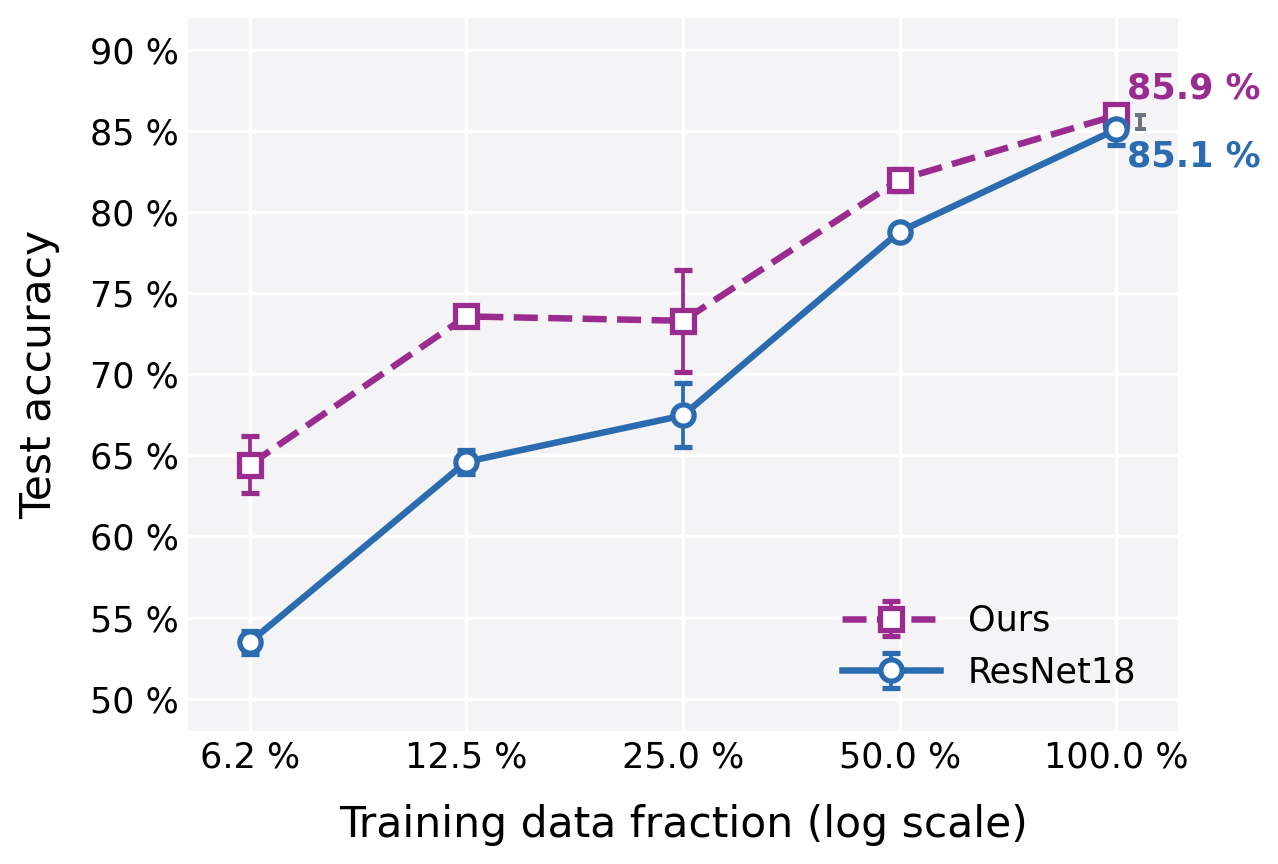

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_df = filtered_df.copy()
plot_df = plot_df.dropna(subset=["model_name", "train_data_fraction", "test_acc"])

plot_summary = (
    plot_df.groupby(["model_name", "train_data_fraction"], as_index=False)
    .agg(
        mean_test_acc=("test_acc", "mean"),
        std_test_acc=("test_acc", "std"),
        n_runs=("test_acc", "count"),
    )
    .sort_values(["model_name", "train_data_fraction"])
)
plot_summary["std_test_acc"] = plot_summary["std_test_acc"].fillna(0.0)

model_labels = {
    "PrototypeOptimal": "Ours",
    "Resnet18": "ResNet18",
    "E2CNN": "E2-CNNs",
    "E2CNNInvariant": "E2-CNNs",
}

style_cycle = [
    {"color": "#2b6cb0", "marker": "o", "linestyle": "-"},
    {"color": "#9b2c8f", "marker": "s", "linestyle": "--"},
    {"color": "#2f855a", "marker": "^", "linestyle": "-."},
    {"color": "#c05621", "marker": "D", "linestyle": ":"},
]
preferred_styles = {
    "E2CNN": style_cycle[0],
    "E2CNNInvariant": style_cycle[0],
    "Resnet18": style_cycle[0],
    "PrototypeOptimal": style_cycle[1],
}

fig, ax = plt.subplots(figsize=(7.2, 4.9), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("#f4f4f6")

for index, (model_name, model_data) in enumerate(plot_summary.groupby("model_name", sort=True)):
    style = preferred_styles.get(model_name, style_cycle[index % len(style_cycle)])
    label = model_labels.get(model_name, model_name)
    ax.errorbar(
        model_data["train_data_fraction"],
        model_data["mean_test_acc"],
        yerr=model_data["std_test_acc"],
        label=label,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=2.6,
        marker=style["marker"],
        markersize=8.5,
        markerfacecolor="white",
        markeredgecolor=style["color"],
        markeredgewidth=2.1,
        capsize=3.5,
        capthick=1.5,
        elinewidth=1.5,
        zorder=3,
    )

ax.set_xscale("log", base=2)
ax.set_xticks(sorted(plot_summary["train_data_fraction"].unique()))
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value * 100:.1f} %"))
ax.set_xlim(
    plot_summary["train_data_fraction"].min() * 0.82,
    plot_summary["train_data_fraction"].max() * 1.22,
)
ax.set_ylim(0.48, min(0.92, plot_summary["mean_test_acc"].max() + 0.06))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value * 100:.0f} %"))

ax.set_xlabel("Training data fraction (log scale)", fontsize=17, labelpad=12)
ax.set_ylabel("Test accuracy", fontsize=17, labelpad=12)
ax.tick_params(axis="both", which="major", labelsize=14, length=0)
ax.grid(True, which="major", color="white", linewidth=1.35)
ax.grid(True, which="minor", color="white", linewidth=0.7, alpha=0.65)

full_data = plot_summary.loc[plot_summary["train_data_fraction"] == plot_summary["train_data_fraction"].max()]
full_means = dict(zip(full_data["model_name"], full_data["mean_test_acc"]))
if {"PrototypeOptimal", "Resnet18"}.issubset(full_means):
    ours_mean = full_means["PrototypeOptimal"]
    baseline_mean = full_means["Resnet18"]
    x_bracket = plot_summary["train_data_fraction"].max() * 1.08
    y_low, y_high = sorted([baseline_mean, ours_mean])
    ax.vlines(x_bracket, y_low, y_high, color="#6b7280", linewidth=1.6, zorder=2)
    ax.hlines([y_low, y_high], x_bracket / 1.018, x_bracket * 1.018, color="#6b7280", linewidth=1.6, zorder=2)
    ax.text(
        1.035,
        ours_mean + 0.006,
        f"{(ours_mean*100):.1f} %",
        color=preferred_styles["PrototypeOptimal"]["color"],
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="left",
    )
    ax.text(
        1.035,
        baseline_mean - 0.006,
        f"{(baseline_mean*100):.1f} %",
        color=preferred_styles["Resnet18"]["color"],
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
    )

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=14,
    handlelength=2.8,
    borderaxespad=0.8,
)
for handle in legend.legend_handles:
    if hasattr(handle, "set_markerfacecolor"):
        handle.set_markerfacecolor("white")

ax.margins(x=0.08)
fig.tight_layout()

figure_path = NOTEBOOK_DIR / "kately_images_train_fraction_test_acc.png"
pdf_path = figure_path.with_suffix(".pdf")
fig.savefig(figure_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(pdf_path, bbox_inches="tight", facecolor=fig.get_facecolor())

figure_path, pdf_path